# 04 — Explainable AI (SHAP + LIME)

**Anaemia Prediction using Machine Learning & Explainable AI** — Phase 6.

> ⚠️ **Disclaimer:** This is an educational decision-support prototype, **not a
> diagnostic tool.** It must not be used for real medical decisions.

This notebook answers the project's core question — *why* does the model predict
anaemia? — using two complementary tools:

- **SHAP** (primary): consistent, game-theory-based feature attributions, both
  global (which features matter overall) and local (why this one patient).
- **LIME** (minimal, one example): a local linear approximation of one
  prediction, as a cross-check on SHAP.

All logic lives in `src/explain.py`; this notebook just calls it and shows the
figures, so the report, the app, and this notebook never drift apart.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make `src` importable from notebooks/

from IPython.display import Image
from src import explain, config

FIG = config.FIGURES_DIR
print("Showcase model:", explain.SHOWCASE_MODEL)
print("Figures ->", FIG)

Showcase model: xgboost
Figures -> /home/Clyton/Projects/AnemiaPrediction/reports/figures


## 1. Global SHAP — which CBC features drive predictions overall?

The **beeswarm** plots every test patient as a dot per feature; colour is the
feature value (red = high, blue = low), position is the SHAP value (right =
pushes toward *anaemic*). The **bar** chart is the mean absolute SHAP — a clean
importance ranking.

**Expectation:** Haemoglobin towers over everything, because the dataset's label
was defined from an Hb threshold. This is the *label-leakage* finding made
visible — and it is the honest centre of our project's story.

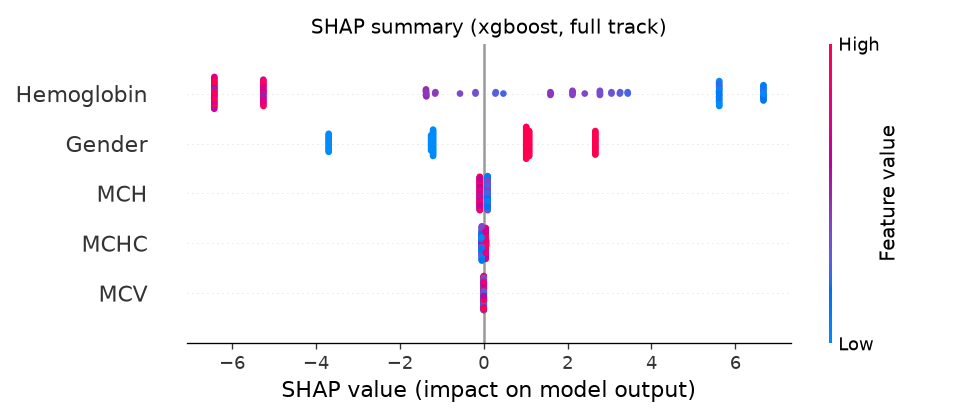

In [2]:
explain.shap_global("full")
Image(filename=str(FIG / "fig_shap_beeswarm_full.png"))

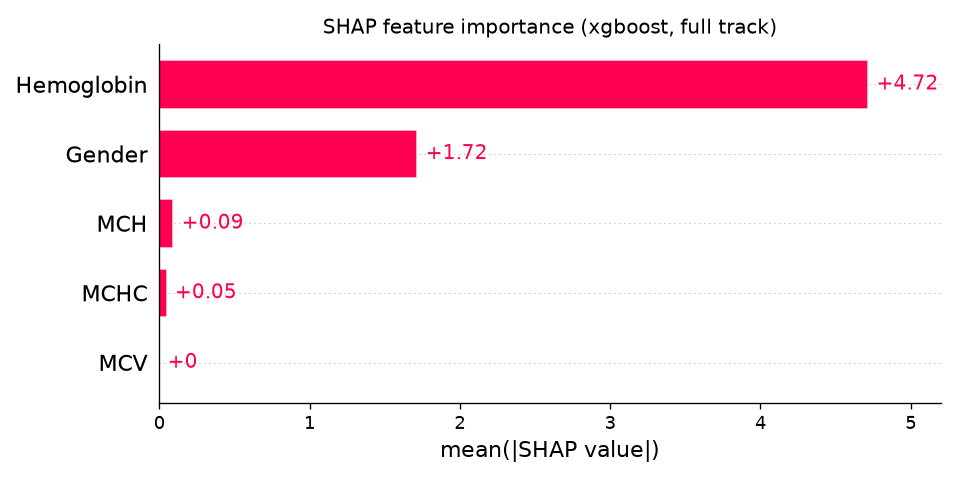

In [3]:
Image(filename=str(FIG / "fig_shap_bar_full.png"))

**Reading it:** low Haemoglobin (blue dots) sits far to the right — strongly
pushing the prediction to *anaemic*. Gender comes second (the WHO cutoff differs
by sex: <12 g/dL for women, <13 for men). MCH/MCHC/MCV barely move the needle.

## 2. Local SHAP — why *this* patient?

A **waterfall** starts at the baseline `E[f(x)]` (the average prediction) and
adds each feature's push until it reaches this patient's score `f(x)`. Feature
values are shown in **real blood units** (not z-scores) for readability.

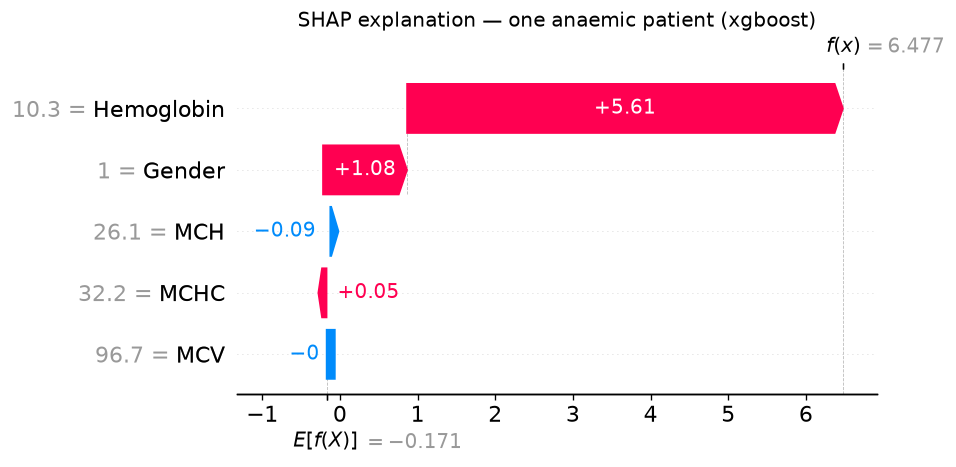

In [4]:
explain.shap_local("full", patient="anaemic")
Image(filename=str(FIG / "fig_shap_waterfall_full_anaemic.png"))

An anaemic patient: a low Haemoglobin reading delivers the dominant positive push.

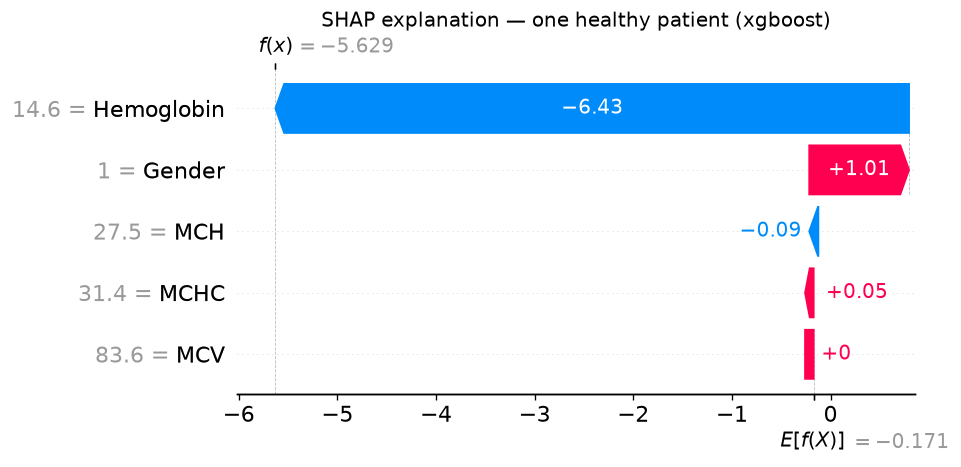

In [5]:
explain.shap_local("full", patient="healthy")
Image(filename=str(FIG / "fig_shap_waterfall_full_healthy.png"))

A healthy patient: a normal/high Haemoglobin pushes the score the other way.

## 3. The honest contrast — SHAP on the Hb-excluded (`nohb`) model

[MARKS-BOOSTER] We retrained with Haemoglobin **removed** to test whether the
other CBC indices carry any real signal. If the full-track success were genuine
medical skill, these features would still separate the classes. They don't.

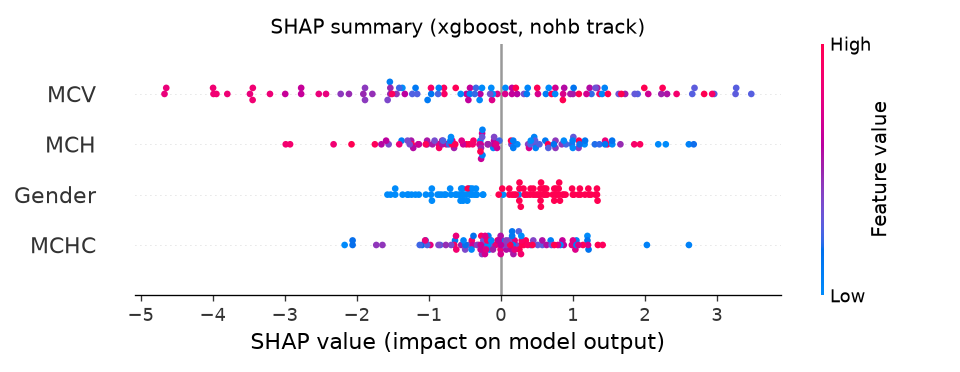

In [6]:
explain.shap_global("nohb")
Image(filename=str(FIG / "fig_shap_beeswarm_nohb.png"))

**Reading it:** no feature dominates and the colour gradients are muddy — high
and low values land on both sides. That is the visual signature of a model with
no real signal (it scores ~50%, near chance). This is exactly what we expect and
*want* to show: the headline accuracy came from Haemoglobin, i.e. from leakage.

## 4. LIME — one local cross-check

LIME fits a tiny interpretable model around a single prediction. We train it on
original units and scale internally, so its rules read in real CBC values.

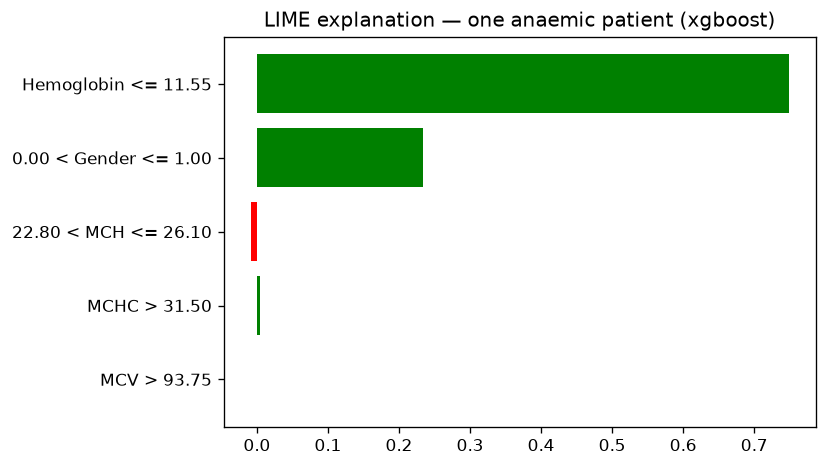

In [7]:
explain.lime_example("full", patient="anaemic")
Image(filename=str(FIG / "fig_lime_full_anaemic.png"))

LIME independently lands on the same story as SHAP — a low-Haemoglobin rule
(e.g. `Hemoglobin <= 11.55`) carries the *anaemic* prediction, with Gender
second. Two different methods agreeing strengthens our confidence in the
explanation.

## Takeaways

1. **Haemoglobin dominates** every view — global, local, SHAP and LIME agree.
2. That dominance is the **label-leakage** finding visualised, not a bug.
3. Removing Hb collapses the model to near-chance — proof the other indices
   carry little signal in *this* dataset.
4. **SHAP and LIME agree**, which is the explainability objective satisfied:
   the model is interpretable, and we can say *why* for any single patient.

> Reminder: educational prototype, **not** a diagnostic tool.